In [1]:
import pandas as pd 
import seaborn as sns

In [2]:
#import data
data = pd.read_csv("HousePricePrediction.csv")
data = data.copy()

In [3]:
data

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,NaN
2915,2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,NaN
2916,2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,NaN
2917,2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,NaN


In [4]:
#fill nan values

data["MSZoning"] = data["MSZoning"].fillna(data["MSZoning"].mode()[0])
data["Exterior1st"] = data["Exterior1st"].fillna(data["Exterior1st"].mode()[0])
data["BsmtFinSF2"] = data["BsmtFinSF2"].fillna(data["BsmtFinSF2"].mode()[0])
data["TotalBsmtSF"] = data["TotalBsmtSF"].fillna(data["TotalBsmtSF"].mode()[0])

In [5]:
data.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        0
BsmtFinSF2         0
TotalBsmtSF        0
SalePrice       1459
dtype: int64

In [6]:
data = data.dropna(subset=["SalePrice"])

In [7]:
#Create data in x,y for better expireance in seaborn
x = data.drop(columns=["SalePrice"])
y = data["SalePrice"]

In [8]:
x

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1455,60,RL,7917,Inside,1Fam,5,1999,2000,VinylSd,0.0,953.0
1456,1456,20,RL,13175,Inside,1Fam,6,1978,1988,Plywood,163.0,1542.0
1457,1457,70,RL,9042,Inside,1Fam,9,1941,2006,CemntBd,0.0,1152.0
1458,1458,20,RL,9717,Inside,1Fam,6,1950,1996,MetalSd,1029.0,1078.0


In [9]:
#convert all catogries values in each different columns
# also True & False in 0 & 1
x = pd.get_dummies(x, drop_first=True)
x = x.astype(int)

In [10]:
y

0       208500.0
1       181500.0
2       223500.0
3       140000.0
4       250000.0
          ...   
1455    175000.0
1456    210000.0
1457    266500.0
1458    142125.0
1459    147500.0
Name: SalePrice, Length: 1460, dtype: float64

<Axes: xlabel='YearBuilt', ylabel='SalePrice'>

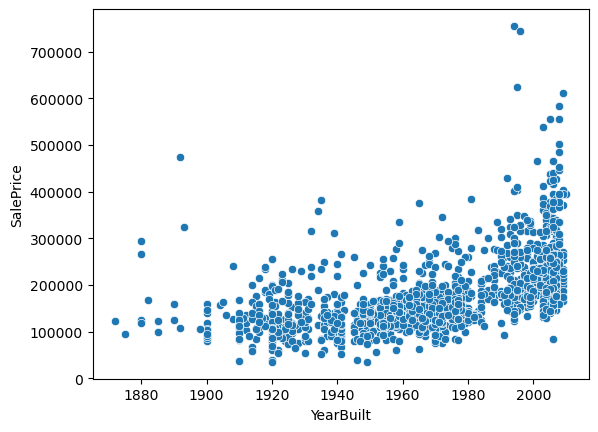

In [11]:
sns.scatterplot(x=x["YearBuilt"], y=y)

In [12]:
# Train Test split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

In [13]:
print(y.isna().sum())


0


In [14]:
# Train Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [15]:
#Predict values
y_pred = model.predict(x_test)

In [16]:
y_pred

array([168733.00189055, 243223.76121104, 114785.4122782 , 157880.21908253,
       254517.60086045, 156703.57888498, 178379.56166675, 127064.11121206,
       133197.4188594 , 149331.19082235, 131000.75218361, 122815.2050272 ,
        79738.39227967, 239339.94776738, 218129.44955194, 177551.1420249 ,
       218101.29975088, 178803.1261605 , 135322.80805372, 233339.70771398,
       163212.59495861, 219590.49747873, 202612.80166674, 154541.464804  ,
       224316.14395911, 167384.05651946, 228422.20457254, 110932.01963278,
       215243.13926239, 205067.00490291, 115672.66061879, 231708.53736396,
       224244.0047091 , 129036.96376607, 251253.52486046, 140922.92968161,
       170428.17798619, 217706.51759572, 254810.7443039 ,  78172.67334397,
       119177.72918109, 218351.79277335, 125276.92523566, 291207.78191568,
       141515.57653548, 104779.22150903, 127608.97846475, 131336.69938212,
       320741.92793949, 146047.68650293, 111720.04894557, 193398.07005701,
       123511.08279431, 2

In [17]:
y_test

892     154500.0
1105    325000.0
413     115000.0
522     159000.0
1036    315500.0
          ...   
479      89471.0
1361    260000.0
802     189000.0
651     108000.0
722     124500.0
Name: SalePrice, Length: 292, dtype: float64

In [18]:
#Evalute
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("r-squared", r2)

n = x_test.shape[0]
p = x_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
print("adjusted r^2 :", adjusted_r2)

r-squared 0.6196387511449772
adjusted r^2 : 0.5693185859268031
